In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

import pandas as pd
import seaborn as sns

: 

: 

: 

In [ ]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

: 

: 

: 

## DF

In [ ]:
# df = pd.read_csv("higher_sweep.csv")
# df = pd.read_csv("week12_normalize_target_sweep.csv")
# df = pd.read_csv("week12_normalize_target_bfactor_sweep.csv")
df = pd.read_csv("results/threshold_voltage_heterogeneity_grid_search.csv")
# df = pd.read_csv("week12_normalize_target_random_topology_sweep.csv")

: 

: 

: 

In [ ]:
df

,job_index,num_jobs,topology,generator_name,topology_seed,variance_ss4_vt,variance_b_vt,truncate_std,heterogeneity_param_index,heterogeneity_param_name,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,1,4,fixed,generate_random_fixed_indegree_ei_network,1234,0.0,0.0,2.0,6,Vt,...,0.021126,0.011176,0.5897,0.5770,0.67040,0.984,0.98000,1.0,84.819381,8.917506
1,2,4,fixed,generate_random_fixed_indegree_ei_network,1234,0.0,0.3,2.0,6,Vt,...,0.007452,0.015414,0.6098,0.6020,0.65665,0.977,0.97125,1.0,119.541886,8.923940
2,3,4,fixed,generate_random_fixed_indegree_ei_network,1234,0.0,0.6,2.0,6,Vt,...,0.006226,0.005230,0.6096,0.6090,0.65135,0.976,0.97000,1.0,107.049386,8.947850
3,0,4,fixed,generate_random_fixed_indegree_ei_network,1234,0.0,1.0,2.0,6,Vt,...,0.018756,0.013793,0.5877,0.5860,0.63695,0.984,0.98000,1.0,90.661905,8.838255
4,1,4,fixed,generate_random_fixed_indegree_ei_network,1234,0.0,2.0,2.0,6,Vt,...,0.008886,0.004678,0.5850,0.5760,0.63615,0.988,0.98500,1.0,148.349102,8.907942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,0,4,spatial,generate_spatial_ei_network,1238,7.0,0.6,2.0,6,Vt,...,0.020023,0.014192,0.7077,0.6955,0.79140,0.999,0.99875,1.0,56.265234,8.116441
486,1,4,spatial,generate_spatial_ei_network,1238,7.0,1.0,2.0,6,Vt,...,0.030199,0.017534,0.6996,0.6930,0.78800,0.992,0.99000,1.0,201.066815,8.133301
487,2,4,spatial,generate_spatial_ei_network,1238,7.0,2.0,2.0,6,Vt,...,0.024675,0.018314,0.6940,0.6825,0.77590,0.998,0.99750,1.0,328.211735,8.217163
488,3,4,spatial,generate_spatial_ei_network,1238,7.0,4.0,2.0,6,Vt,...,0.040684,0.034639,0.6892,0.6810,0.82105,0.999,0.99875,1.0,128.129111,7.611551


: 

: 

: 

In [ ]:
# df with removed columns generator_name, num_jobs, job_index, topology_seed
df = df.drop(columns=["generator_name", "num_jobs", "job_index", "topology_seed", "heterogeneity_param_name", "normalize_mode_topology", "runtime_plasticity", "runtime_rate_normalization"])

: 

: 

: 

In [ ]:
df

,topology,variance_ss4_vt,variance_b_vt,truncate_std,heterogeneity_param_index,n_neurons,fixed_indegree,dt_ms,sim_ms,input_rate_hz,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,fixed,0.0,0.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.021126,0.011176,0.5897,0.5770,0.67040,0.984,0.98000,1.0,84.819381,8.917506
1,fixed,0.0,0.3,2.0,6,1000,100,0.1,3000.0,50.0,...,0.007452,0.015414,0.6098,0.6020,0.65665,0.977,0.97125,1.0,119.541886,8.923940
2,fixed,0.0,0.6,2.0,6,1000,100,0.1,3000.0,50.0,...,0.006226,0.005230,0.6096,0.6090,0.65135,0.976,0.97000,1.0,107.049386,8.947850
3,fixed,0.0,1.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.018756,0.013793,0.5877,0.5860,0.63695,0.984,0.98000,1.0,90.661905,8.838255
4,fixed,0.0,2.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.008886,0.004678,0.5850,0.5760,0.63615,0.988,0.98500,1.0,148.349102,8.907942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,spatial,7.0,0.6,2.0,6,1000,100,0.1,3000.0,50.0,...,0.020023,0.014192,0.7077,0.6955,0.79140,0.999,0.99875,1.0,56.265234,8.116441
486,spatial,7.0,1.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.030199,0.017534,0.6996,0.6930,0.78800,0.992,0.99000,1.0,201.066815,8.133301
487,spatial,7.0,2.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.024675,0.018314,0.6940,0.6825,0.77590,0.998,0.99750,1.0,328.211735,8.217163
488,spatial,7.0,4.0,2.0,6,1000,100,0.1,3000.0,50.0,...,0.040684,0.034639,0.6892,0.6810,0.82105,0.999,0.99875,1.0,128.129111,7.611551


: 

: 

: 

In [ ]:
# Meaned df by same variance_ss4_vt and variance_b_vt
grouped_df = df.groupby(["topology", "variance_ss4_vt", "variance_b_vt"]).mean().reset_index()
grouped_df

,topology,variance_ss4_vt,variance_b_vt,truncate_std,heterogeneity_param_index,n_neurons,fixed_indegree,dt_ms,sim_ms,input_rate_hz,...,mean_noise_corr_500ms,mean_noise_corr_1000ms,participation_frac_mean_300ms,participation_frac_median_300ms,participation_frac_p95_300ms,participation_frac_total,participation_frac_total_E,participation_frac_total_I,psd_peak_ratio,pop_spec_entropy
0,fixed,0.0,0.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.011939,0.006503,0.58356,0.5785,0.64619,0.9818,0.97725,1.0,106.523175,8.902490
1,fixed,0.0,0.3,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.010710,0.013102,0.58942,0.5831,0.65183,0.9812,0.97650,1.0,120.152315,8.931644
2,fixed,0.0,0.6,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.010282,0.010377,0.59192,0.5890,0.64627,0.9814,0.97675,1.0,134.978415,8.911940
3,fixed,0.0,1.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.011262,0.010338,0.58404,0.5743,0.64800,0.9844,0.98050,1.0,142.370912,8.875791
4,fixed,0.0,2.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.012958,0.010884,0.57838,0.5757,0.64354,0.9846,0.98075,1.0,145.606649,8.888548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,spatial,7.0,0.6,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.020315,0.014182,0.69298,0.6796,0.77981,0.9994,0.99925,1.0,170.377172,8.080918
94,spatial,7.0,1.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.025122,0.011831,0.68740,0.6871,0.77915,0.9966,0.99575,1.0,154.254047,8.079951
95,spatial,7.0,2.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.049655,0.043963,0.67148,0.6851,0.77762,0.9986,0.99825,1.0,231.468520,7.866026
96,spatial,7.0,4.0,2.0,6.0,1000.0,100.0,0.1,3000.0,50.0,...,0.037369,0.029627,0.67668,0.6717,0.77272,0.9960,0.99500,1.0,195.665065,7.879017


: 

: 

: 

## Heatmaps

### PSD peak ratio

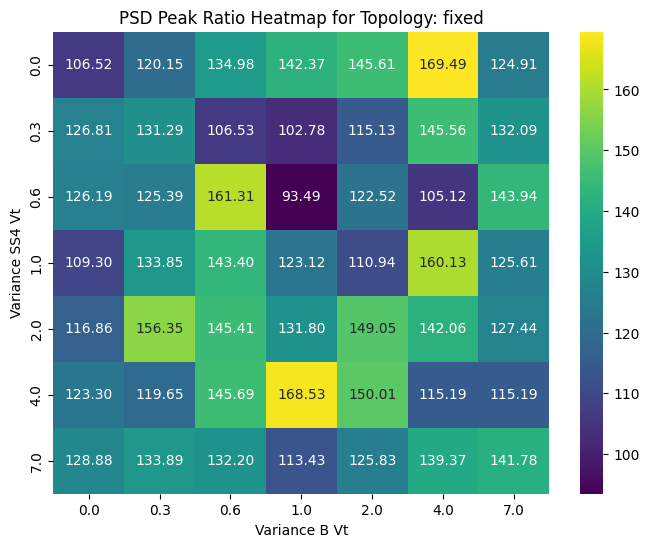

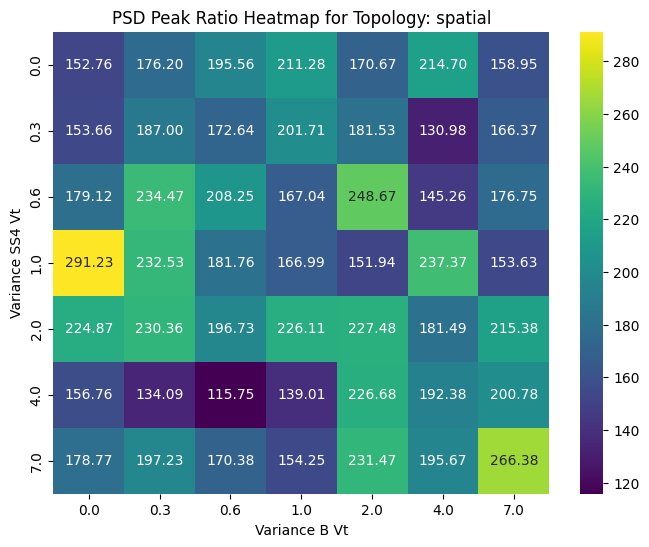

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="psd_peak_ratio")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"PSD Peak Ratio Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### Noise correlation

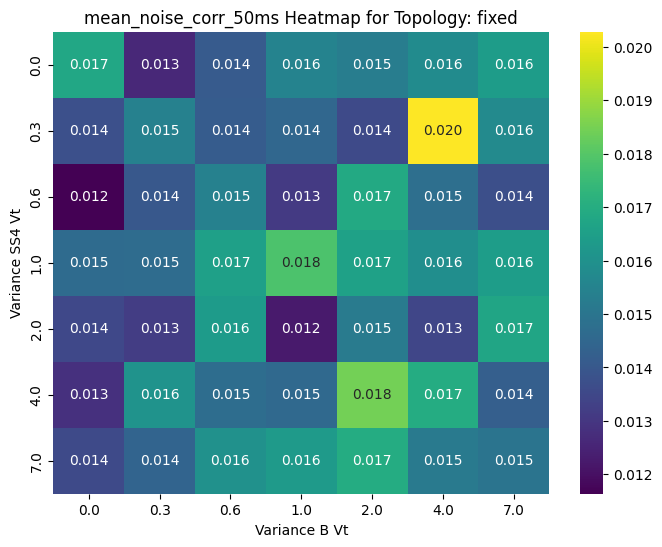

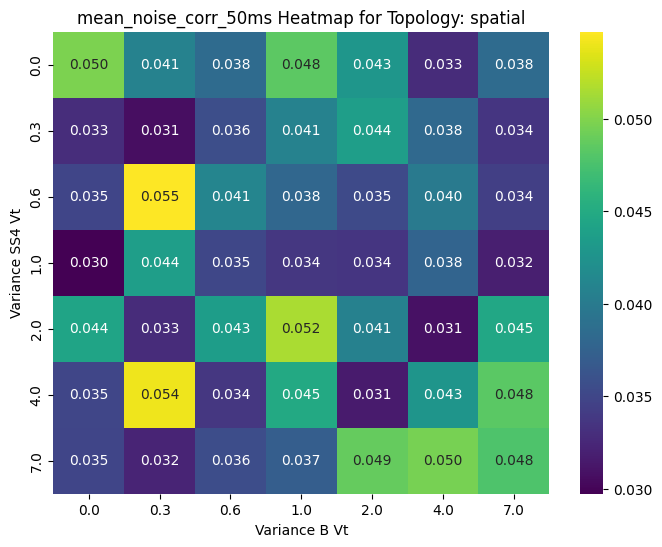

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="mean_noise_corr_50ms")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"mean_noise_corr_50ms Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### ISI CV

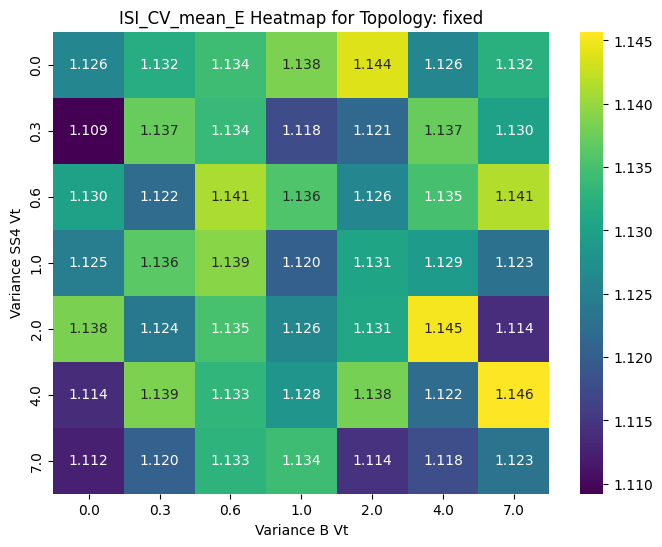

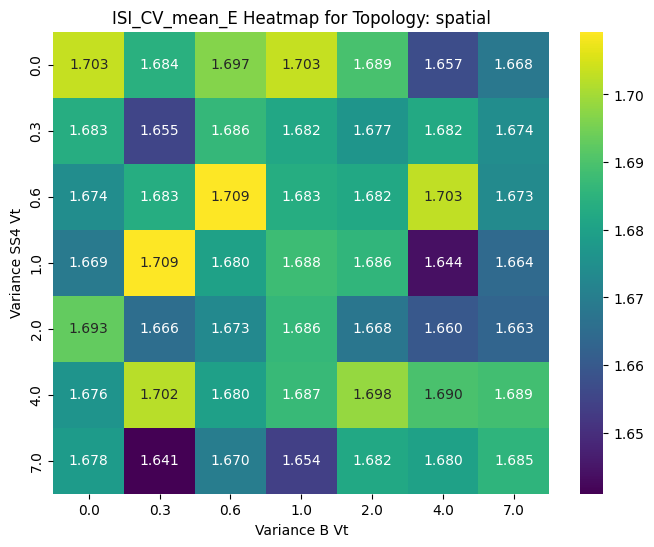

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="ISI_CV_mean_E")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"ISI_CV_mean_E Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

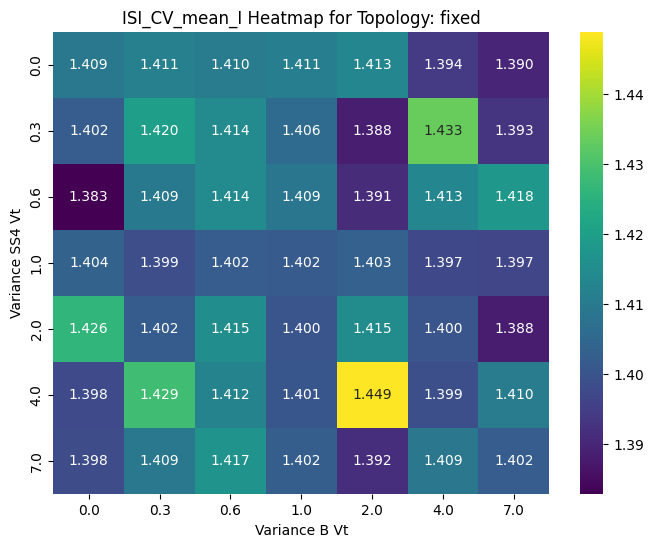

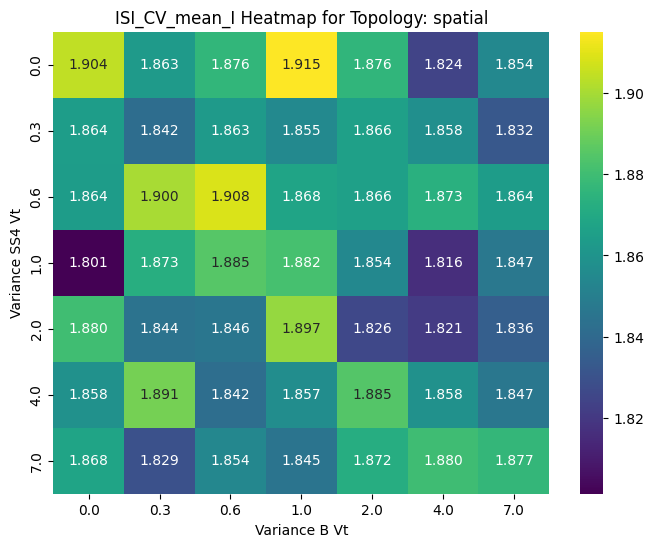

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="ISI_CV_mean_I")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"ISI_CV_mean_I Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### Fano

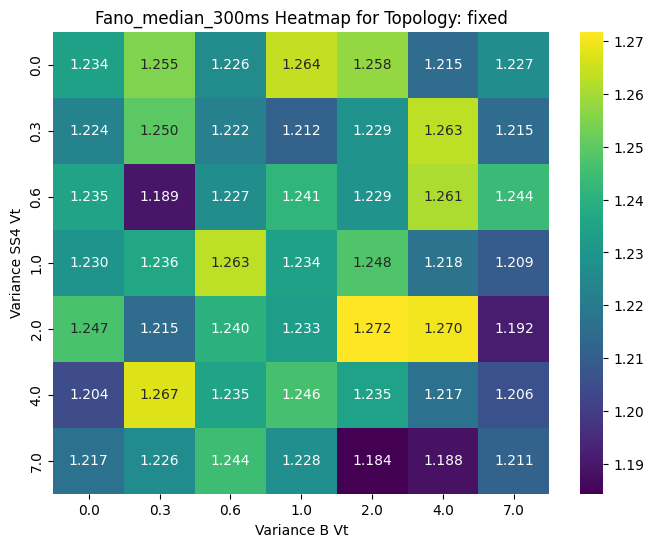

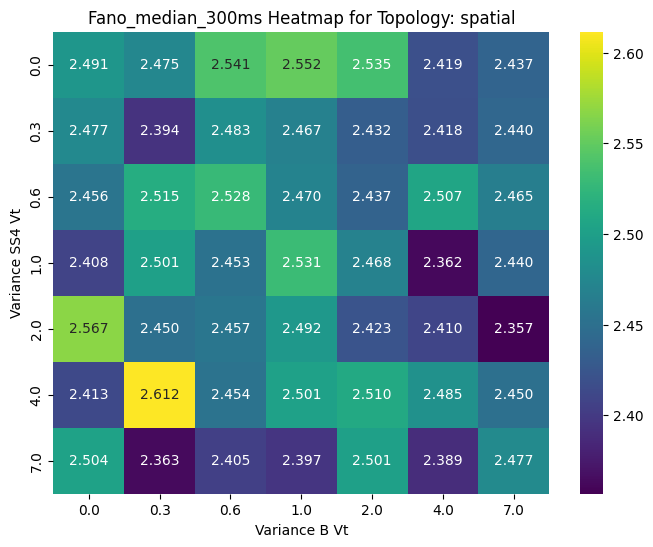

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="Fano_median_300ms")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Fano_median_300ms Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

### Spiking rate

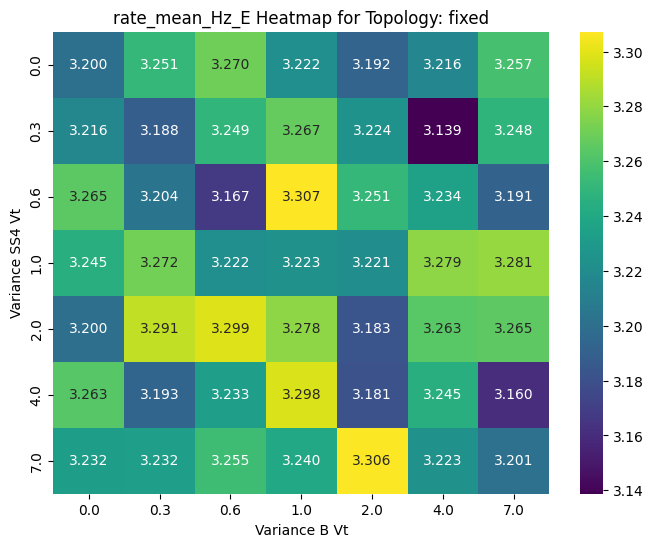

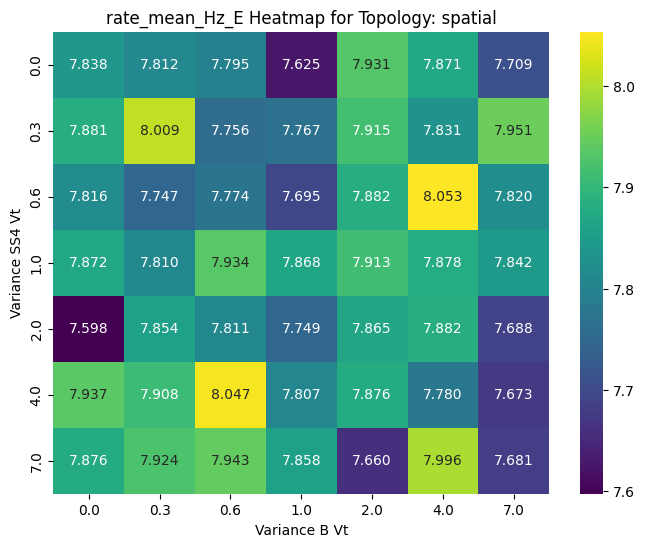

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="rate_mean_Hz_E")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"rate_mean_Hz_E Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

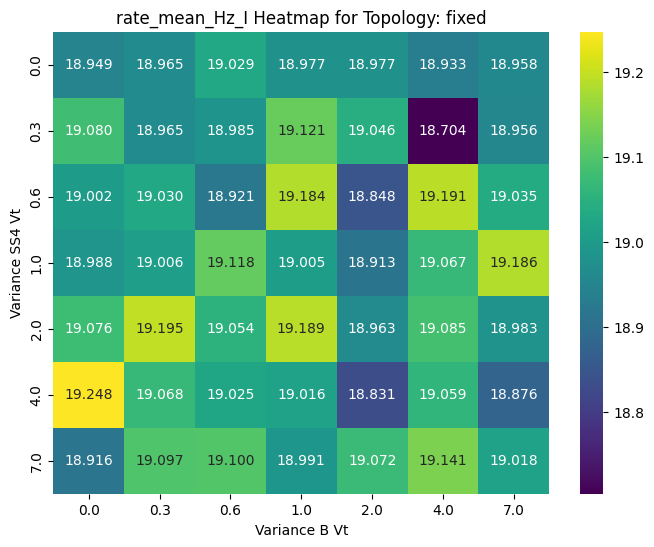

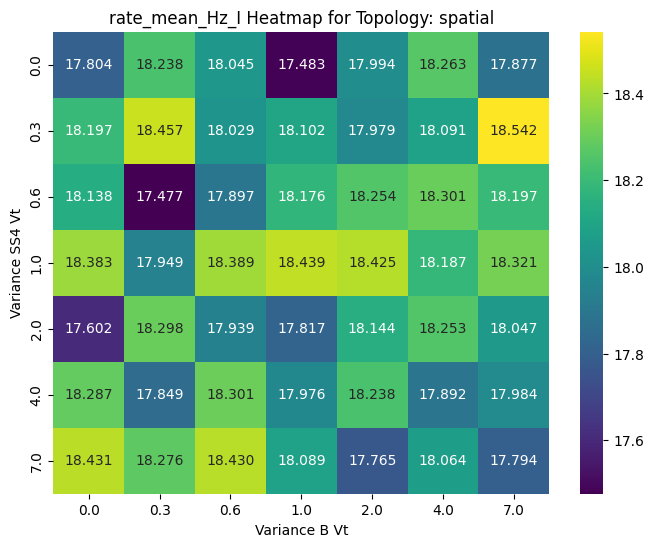

: 

: 

: 

In [ ]:
# psd_peak_ratio heatmap for variance_ss4_vt vs variance_b_vt for each topology
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    pivot_table = subset.pivot(index="variance_ss4_vt", columns="variance_b_vt", values="rate_mean_Hz_I")
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"rate_mean_Hz_I Heatmap for Topology: {topology}")
    plt.xlabel("Variance B Vt")
    plt.ylabel("Variance SS4 Vt")
    plt.show()

## Correlations

Correlations for Topology: fixed
Correlation with psd_peak_ratio:
                 variance_ss4_vt  variance_b_vt  psd_peak_ratio
variance_ss4_vt     1.000000e+00   1.310288e-17        0.071714
variance_b_vt       1.310288e-17   1.000000e+00        0.106484
psd_peak_ratio      7.171374e-02   1.064843e-01        1.000000

Correlation with mean_noise_corr_50ms:
                      variance_ss4_vt  variance_b_vt  mean_noise_corr_50ms
variance_ss4_vt          1.000000e+00   1.310288e-17              0.052483
variance_b_vt            1.310288e-17   1.000000e+00              0.271388
mean_noise_corr_50ms     5.248344e-02   2.713883e-01              1.000000

Correlation with ISI_CV_mean_E:
                 variance_ss4_vt  variance_b_vt  ISI_CV_mean_E
variance_ss4_vt     1.000000e+00   1.310288e-17      -0.269094
variance_b_vt       1.310288e-17   1.000000e+00       0.066461
ISI_CV_mean_E      -2.690939e-01   6.646091e-02       1.000000

Correlation with ISI_CV_mean_I:
                 var

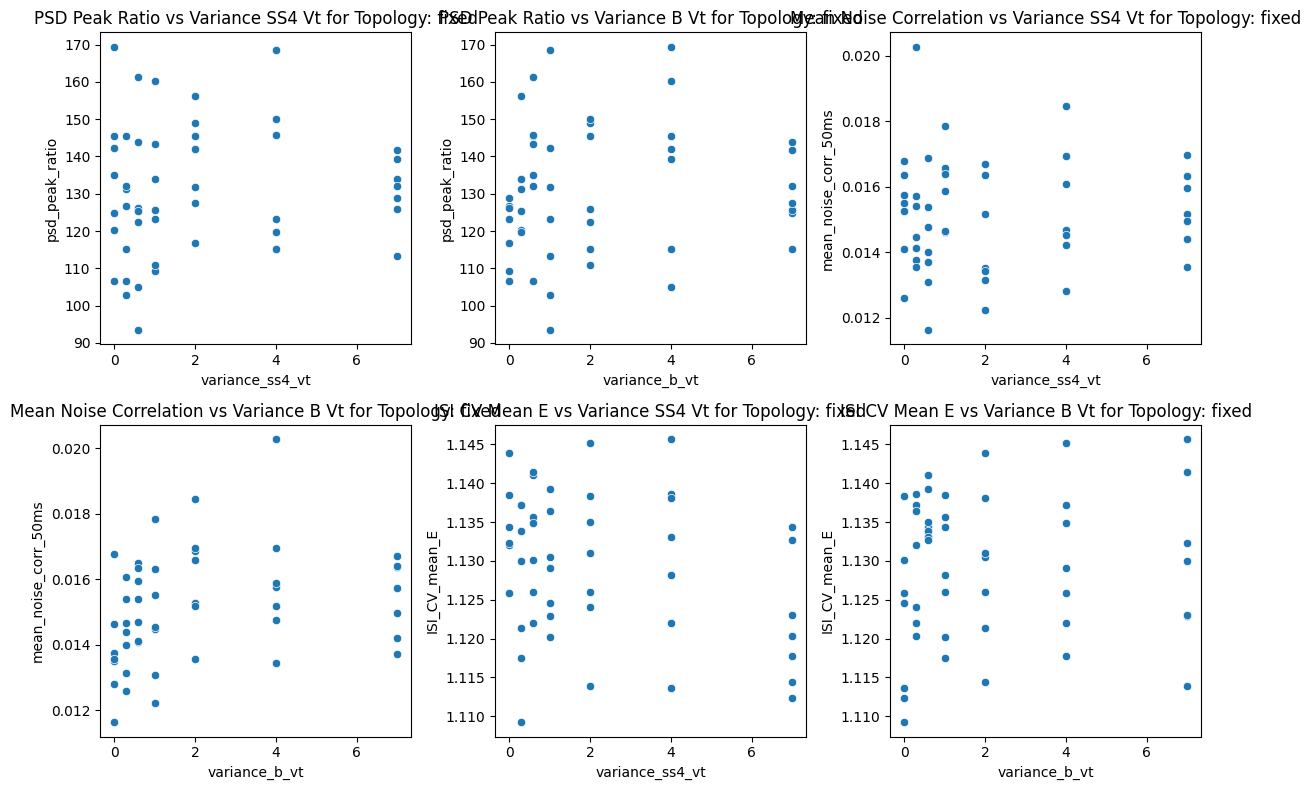

Correlations for Topology: spatial
Correlation with psd_peak_ratio:
                 variance_ss4_vt  variance_b_vt  psd_peak_ratio
variance_ss4_vt     1.000000e+00   1.310288e-17        0.046399
variance_b_vt       1.310288e-17   1.000000e+00        0.010738
psd_peak_ratio      4.639886e-02   1.073774e-02        1.000000

Correlation with mean_noise_corr_50ms:
                      variance_ss4_vt  variance_b_vt  mean_noise_corr_50ms
variance_ss4_vt          1.000000e+00   1.310288e-17              0.143326
variance_b_vt            1.310288e-17   1.000000e+00              0.017617
mean_noise_corr_50ms     1.433256e-01   1.761657e-02              1.000000

Correlation with ISI_CV_mean_E:
                 variance_ss4_vt  variance_b_vt  ISI_CV_mean_E
variance_ss4_vt     1.000000e+00   1.310288e-17      -0.179535
variance_b_vt       1.310288e-17   1.000000e+00      -0.211397
ISI_CV_mean_E      -1.795346e-01  -2.113967e-01       1.000000

Correlation with ISI_CV_mean_I:
                 v

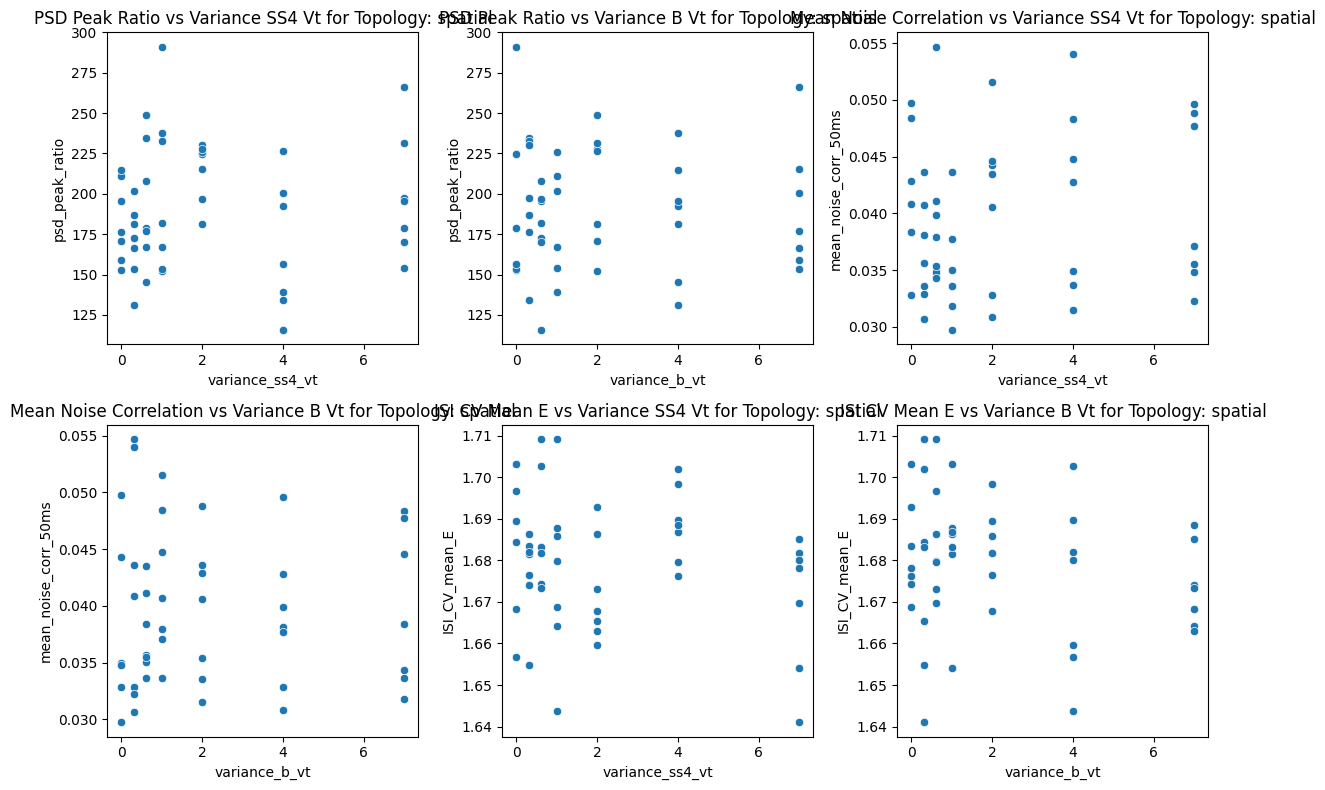

: 

: 

: 

In [ ]:
# Correlations for variance_ss4_vt and variance_b_vt for each topology, vs psd_peak_ratio, mean_noise_corr_50ms, ISI_CV_mean_E, ISI_CV_mean_I, Fano_median_300ms
for topology in grouped_df["topology"].unique():
    subset = grouped_df[grouped_df["topology"] == topology]
    corr_psd_peak_ratio = subset[["variance_ss4_vt", "variance_b_vt", "psd_peak_ratio"]].corr()
    corr_mean_noise_corr_50ms = subset[["variance_ss4_vt", "variance_b_vt", "mean_noise_corr_50ms"]].corr()
    corr_ISI_CV_mean_E = subset[["variance_ss4_vt", "variance_b_vt", "ISI_CV_mean_E"]].corr()
    corr_ISI_CV_mean_I = subset[["variance_ss4_vt", "variance_b_vt", "ISI_CV_mean_I"]].corr()
    corr_Fano_median_300ms = subset[["variance_ss4_vt", "variance_b_vt", "Fano_median_300ms"]].corr()
    corr_rate_mean_Hz_E = subset[["variance_ss4_vt", "variance_b_vt", "rate_mean_Hz_E"]].corr()
    corr_rate_mean_Hz_I = subset[["variance_ss4_vt", "variance_b_vt", "rate_mean_Hz_I"]].corr()
    
    print(f"Correlations for Topology: {topology}")
    print("Correlation with psd_peak_ratio:")
    print(corr_psd_peak_ratio)
    print("\nCorrelation with mean_noise_corr_50ms:")
    print(corr_mean_noise_corr_50ms)
    print("\nCorrelation with ISI_CV_mean_E:")
    print(corr_ISI_CV_mean_E)
    print("\nCorrelation with ISI_CV_mean_I:")
    print(corr_ISI_CV_mean_I)
    print("\nCorrelation with Fano_median_300ms:")
    print(corr_Fano_median_300ms)
    print("\nCorrelation with rate_mean_Hz_E:")
    print(corr_rate_mean_Hz_E)
    print("\nCorrelation with rate_mean_Hz_I:")
    print(corr_rate_mean_Hz_I)
    print("\n" + "="*50 + "\n")

    # Plot
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 3, 1)
    sns.scatterplot(data=subset, x="variance_ss4_vt", y="psd_peak_ratio")
    plt.title(f"PSD Peak Ratio vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 2)
    sns.scatterplot(data=subset, x="variance_b_vt", y="psd_peak_ratio")
    plt.title(f"PSD Peak Ratio vs Variance B Vt for Topology: {topology}")
    plt.subplot(2, 3, 3)
    sns.scatterplot(data=subset, x="variance_ss4_vt", y="mean_noise_corr_50ms")
    plt.title(f"Mean Noise Correlation vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 4)
    sns.scatterplot(data=subset, x="variance_b_vt", y="mean_noise_corr_50ms")
    plt.title(f"Mean Noise Correlation vs Variance B Vt for Topology: {topology}")
    plt.subplot(2, 3, 5)
    sns.scatterplot(data=subset, x="variance_ss4_vt", y="ISI_CV_mean_E")
    plt.title(f"ISI CV Mean E vs Variance SS4 Vt for Topology: {topology}")
    plt.subplot(2, 3, 6)
    sns.scatterplot(data=subset, x="variance_b_vt", y="ISI_CV_mean_E")
    plt.title(f"ISI CV Mean E vs Variance B Vt for Topology: {topology}")
    plt.tight_layout()
    plt.show()

## Find AI

In [ ]:
ai_columns = ["Fano_median_300ms", "ISI_CV_mean_E", "mean_noise_corr_50ms", "psd_peak_ratio"]
thresholds = [0.95, 0.95, 0.05, 100.0]
threshold_is_higher = [True, True, False, False]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df = filtered_df[filtered_df[col] >= thresh]
    else:
        filtered_df = filtered_df[filtered_df[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df = filtered_df[(filtered_df[col] >= min_val) & (filtered_df[col] <= max_val)]

: 

: 

: 

In [ ]:
relevant_columns = parameter_columns.tolist() + ai_columns

NameError: name 'parameter_columns' is not defined

: 

: 

: 

In [ ]:
relevant_columns = relevant_columns + ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I", "participation_frac_median_300ms", "participation_frac_total", "refractory_violations_per_neuron", "min_voltage_mV_E", "min_voltage_mV_I", "ISI_CV_mean_E", "ISI_CV_mean_I"]

: 

: 

: 

In [ ]:
df[relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
0,5.0,0.5,50.0,10.0,0.363636,1.095887,0.532689,10989.667821,10.565193,1.624838,-62.797819,-54.326118,0.876,0.945,0.0,-99.998616,-99.882736,1.095887,0.612724
1,5.0,0.5,50.0,25.0,0.400000,1.173517,0.570224,7736.984999,11.165133,1.294871,-62.902161,-54.533038,0.860,0.932,0.0,-99.998616,-99.882736,1.173517,0.657381
2,5.0,0.5,50.0,50.0,0.500000,1.106107,0.507692,2932.680564,11.721328,1.254875,-62.812276,-54.867264,0.862,0.921,0.0,-99.998616,-99.882736,1.106107,0.568501
3,5.0,0.5,50.0,100.0,0.363636,1.175690,0.523725,8562.160226,11.155134,1.034897,-62.874744,-55.317777,0.857,0.899,0.0,-99.998616,-99.882736,1.175690,0.653565
4,5.0,0.5,50.0,250.0,0.363636,1.144842,0.502659,8649.270098,11.205129,0.814919,-62.847659,-56.312431,0.844,0.884,0.0,-99.998616,-99.882736,1.144842,0.733290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,50.0,20.0,1000.0,10.0,1.500000,1.050418,0.113976,544.680180,1.288621,9.384062,-70.629686,-55.083647,0.264,0.567,0.0,-99.998616,-99.882736,1.050418,2.088134
621,50.0,20.0,1000.0,25.0,1.500000,1.155587,0.103080,527.689489,1.516098,9.124088,-70.630300,-56.047379,0.364,0.623,0.0,-99.998616,-99.882736,1.155587,1.925279
622,50.0,20.0,1000.0,50.0,2.000000,1.362705,0.098306,509.364052,2.092291,9.564044,-70.819044,-57.555502,0.398,0.669,0.0,-99.998616,-99.882736,1.362705,2.030033
623,50.0,20.0,1000.0,100.0,2.000000,1.471901,0.077335,279.209644,3.642136,11.343866,-70.185377,-59.200101,0.417,0.810,0.0,-99.998616,-99.882736,1.471901,2.057756


: 

: 

: 

In [ ]:
filtered_df[relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
249,10.0,20.0,1000.0,250.0,1.000000,0.989338,0.013541,91.901488,0.814919,4.424558,-67.343773,-60.840773,0.220,0.515,0.0,-99.998616,-127.699676,0.989338,1.506169
592,50.0,10.0,500.0,50.0,1.869565,1.597036,0.040409,97.530380,9.585291,20.497950,-66.832198,-57.378618,0.746,0.978,0.0,-99.998616,-99.882736,1.597036,1.736668


: 

: 

: 

In [ ]:
best_rows = [186, 255, 185]

: 

: 

: 

In [ ]:
# Parameters of best rows
df.iloc[best_rows][relevant_columns]

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b,Fano_median_300ms,ISI_CV_mean_E,mean_noise_corr_50ms,psd_peak_ratio,rate_mean_Hz_E,rate_mean_Hz_I,mean_voltage_mV_E,mean_voltage_mV_I,participation_frac_median_300ms,participation_frac_total,refractory_violations_per_neuron,min_voltage_mV_E,min_voltage_mV_I,ISI_CV_mean_E,ISI_CV_mean_I
186,10.0,5.0,250.0,25.0,1.000000,0.984504,0.053683,462.310302,2.782222,7.224278,-64.734929,-55.853731,0.586,0.920,0.0,-99.998616,-99.882736,0.984504,1.200768
255,20.0,0.5,100.0,10.0,0.058824,3.749491,0.939050,2632.752804,50.573693,8.774123,-62.553574,-53.581367,1.000,1.000,0.0,-99.998616,-99.882736,3.749491,1.536055
185,10.0,5.0,250.0,10.0,1.000000,1.049520,0.057029,596.458015,2.243526,7.249275,-64.936711,-54.967534,0.515,0.876,0.0,-99.998616,-99.882736,1.049520,1.182718


: 

: 

: 

## Find SI

In [ ]:
threshold_is_higher = [True, True, True, True]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_SI = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_SI = filtered_df_SI[filtered_df_SI[col] >= thresh]
    else:
        filtered_df_SI = filtered_df_SI[filtered_df_SI[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_SI = filtered_df_SI[(filtered_df_SI[col] >= min_val) & (filtered_df_SI[col] <= max_val)]

: 

: 

: 

## Find SR

In [ ]:
threshold_is_higher = [False, False, True, True]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_SR = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_SR = filtered_df_SR[filtered_df_SR[col] >= thresh]
    else:
        filtered_df_SR = filtered_df_SR[filtered_df_SR[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_SR = filtered_df_SR[(filtered_df_SR[col] >= min_val) & (filtered_df_SR[col] <= max_val)]

: 

: 

: 

## Find AR

In [ ]:
threshold_is_higher = [False, False, False, False]

regime_columns = ["rate_mean_Hz_E", "rate_mean_Hz_I", "mean_voltage_mV_E", "mean_voltage_mV_I"]
regime_ranges = {
    "rate_mean_Hz_E": (0.5, 10.0),
    "rate_mean_Hz_I": (1.0, 200.0),
    "mean_voltage_mV_E": (-80.0, -45.0),
    "mean_voltage_mV_I": (-80.0, -40.0)
}
 
# Filter out rows according to the thresholds
filtered_df_AR = df.copy()
for col, thresh, is_higher in zip(ai_columns, thresholds, threshold_is_higher):
    if is_higher:
        filtered_df_AR = filtered_df_AR[filtered_df_AR[col] >= thresh]
    else:
        filtered_df_AR = filtered_df_AR[filtered_df_AR[col] <= thresh]

# Further filter rows according to the regime ranges
for col, (min_val, max_val) in regime_ranges.items():
    filtered_df_AR = filtered_df_AR[(filtered_df_AR[col] >= min_val) & (filtered_df_AR[col] <= max_val)]

: 

: 

: 

## Analyze

In [ ]:
# Average parameters of each filtered dataframe
filtered_df_AI = filtered_df.copy()
filtered_dfs = [filtered_df_AI, filtered_df_SI, filtered_df_SR, filtered_df_AR]
average_parameters = pd.DataFrame({col: [df[col].mean() for df in filtered_dfs] for col in parameter_columns})
average_parameters

,normalize_target_in_E_ss4,normalize_target_in_E_b,normalize_target_in_I_ss4,normalize_target_in_I_b
0,30.000000,15.000000,750.000000,150.000000
1,25.205479,10.698630,677.397260,59.520548
2,5.476190,2.380952,195.238095,80.476190
3,5.000000,9.375000,87.500000,74.375000


: 

: 

: 

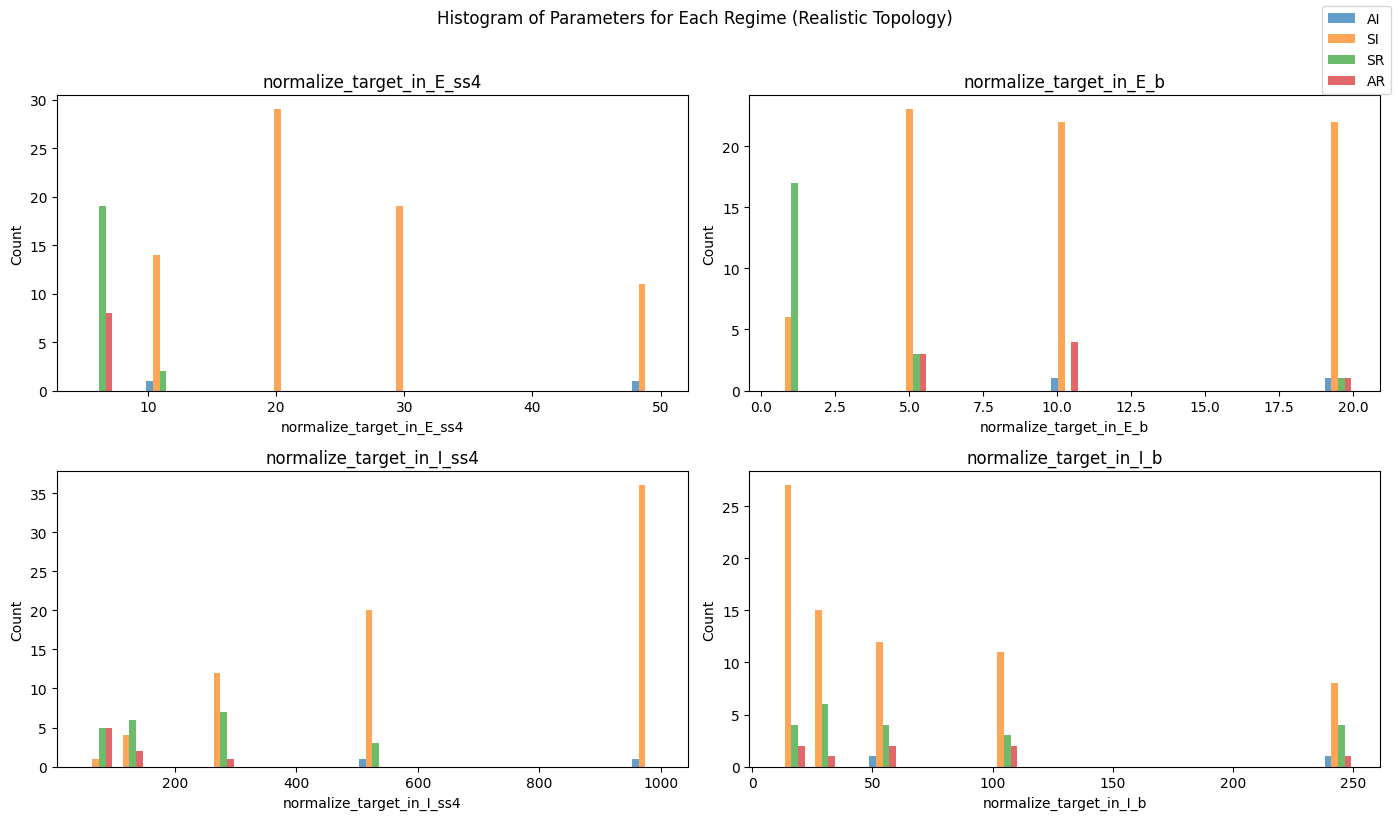

: 

: 

: 

In [ ]:
# Find bins for each parameter based on the combined range across all filtered dataframes
bins_dict = {}
for col in parameter_columns:
    combined_min = min(
        filtered_df_AI[col].min(),
        filtered_df_SI[col].min(),
        filtered_df_SR[col].min(),
        filtered_df_AR[col].min(),
    )
    combined_max = max(
        filtered_df_AI[col].max(),
        filtered_df_SI[col].max(),
        filtered_df_SR[col].max(),
        filtered_df_AR[col].max(),
    )
    bins_dict[col] = np.linspace(combined_min, combined_max, 20)

# One figure with subplots (one per parameter)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(parameter_columns):
    ax = axes[i]
    bins = bins_dict[col]
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]
    bar_width = bin_width * 0.22

    counts_ai, _ = np.histogram(filtered_df_AI[col], bins=bins)
    counts_si, _ = np.histogram(filtered_df_SI[col], bins=bins)
    counts_sr, _ = np.histogram(filtered_df_SR[col], bins=bins)
    counts_ar, _ = np.histogram(filtered_df_AR[col], bins=bins)

    ax.bar(centers - 1.5 * bar_width, counts_ai, width=bar_width, alpha=0.7, label="AI")
    ax.bar(centers - 0.5 * bar_width, counts_si, width=bar_width, alpha=0.7, label="SI")
    ax.bar(centers + 0.5 * bar_width, counts_sr, width=bar_width, alpha=0.7, label="SR")
    ax.bar(centers + 1.5 * bar_width, counts_ar, width=bar_width, alpha=0.7, label="AR")

    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(col)

# Shared legend and title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Histogram of Parameters for Each Regime (Realistic Topology)", y=1.02)
fig.tight_layout()
plt.show()

: 

: 

: 